In [74]:
import os
import gc
import math
import zipfile
import requests
import cdsapi
import pandas as pd
import geopandas as gpd
import osmnx as ox
import pyrosm
import rasterio
import rasterio.plot
import rioxarray
from rasterio import features
from rasterio.warp import Resampling
from rasterio.transform import Affine
import numpy as np
from shapely.geometry import box, Point
from pathlib import Path
import matplotlib.pyplot as plt
import rioxarray
from rasterio.warp import Resampling
from simpledbf import Dbf5

# Magic command to ensure plots render correctly in the notebook
%matplotlib inline


print("All packages imported successfully.")

All packages imported successfully.


In [75]:
# --- Constants ---
TARGET_CRS = "EPSG:32632"  # UTM Zone 32N
BUFFER_METERS = 1000       # 1km buffer
PIXEL_SIZE = 10            # 10m resolution
AOI_NAME = "Kanton Schaffhausen" # Geocoding query

# --- Directories ---
BASE_DIR = Path.cwd().parent.parent
DATA_DIR = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"

# Create directories if they don't exist
DATA_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# --- Input File Paths ---
# Cost tables
OSM_COST_CSV_PATH = DATA_DIR / "resistance_costs.csv"
CLC_COST_CSV_PATH = DATA_DIR / "clc_resistance_costs.csv"

# Raw data (will be downloaded)
PBF_PATH_DE = DATA_DIR / "baden-wuerttemberg-latest.osm.pbf"
PBF_PATH_CH = DATA_DIR / "switzerland-latest.osm.pbf"
CLC_RAW_PATH = DATA_DIR / "clc_2018_10m_raw.tif"
CLC_DOWNLOAD_ZIP = DATA_DIR / "clc_2018_temp.zip"

# --- Processed Cache File Paths ---
PROCESSED_OSM_CACHE = DATA_DIR / "processed_osm_data.gpkg"
CLC_RECLASSIFIED_PATH = RESULTS_DIR / "temp_clc_reclassified_10m.tif"

# --- Intermediate Raster Paths ---
OSM_LANDCOVER_GAPPY = RESULTS_DIR / "temp_osm_landcover_gappy.tif"
FILLED_LANDCOVER_RASTER = RESULTS_DIR / "temp_filled_landcover.tif"
WATER_BARRIER_RASTER = RESULTS_DIR / "temp_water_barrier.tif"
ROAD_BARRIER_RASTER = RESULTS_DIR / "temp_road_barrier.tif"

# --- Final Output ---
FINAL_RASTER = RESULTS_DIR / "final_resistance_surface.tif"

print(f"Base Directory:    {BASE_DIR}")
print(f"Data Directory:    {DATA_DIR}")
print(f"Results Directory: {RESULTS_DIR}")

Base Directory:    c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors
Data Directory:    c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\data
Results Directory: c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\results


1. Defining AOI from 'Kanton Schaffhausen'...
   Buffering polygon by 1000m...
   Final rectangular AOI defined.


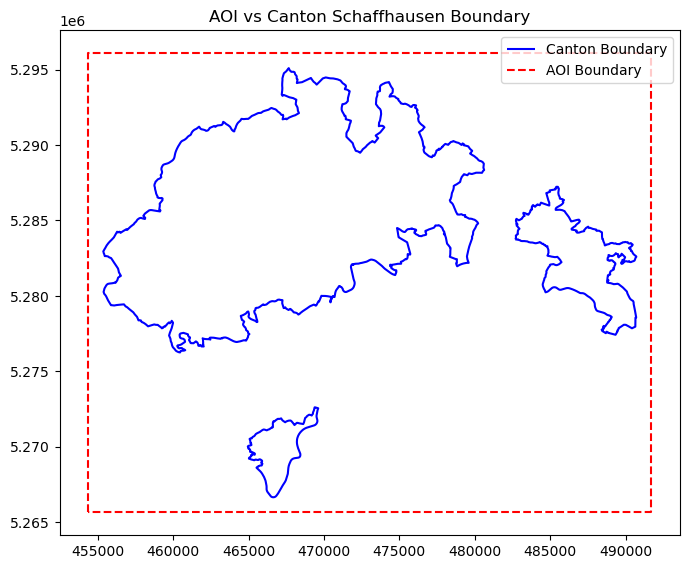

In [76]:
# --- AOI Definition ---
print(f"1. Defining AOI from '{AOI_NAME}'...")

# Get Schaffhausen boundary in WGS84
gdf_sh_wgs = ox.geocode_to_gdf(AOI_NAME)

# Reproject to target CRS (UTM 32N)
gdf_sh_proj = gdf_sh_wgs.to_crs(TARGET_CRS)

# Buffer the polygon first
print(f"   Buffering polygon by {BUFFER_METERS}m...")
buffered_polygon = gdf_sh_proj.buffer(BUFFER_METERS)
bounds = buffered_polygon.total_bounds

# Create a Shapely polygon for the final AOI
aoi_poly = box(*bounds)
print(f"   Final rectangular AOI defined.")

# Create a WGS84 version of the AOI for data fetching
aoi_poly_wgs = gpd.GeoSeries([aoi_poly], crs=TARGET_CRS).to_crs("EPSG:4326").iloc[0]
aoi_bounds_wgs = aoi_poly_wgs.bounds

# Plot the AOI vs canton boundary
fig, ax = plt.subplots(figsize=(8, 8))
aoi_gdf = gpd.GeoDataFrame(geometry=[aoi_poly], crs=TARGET_CRS)
gdf_sh_proj.boundary.plot(ax=ax, edgecolor='blue', label='Canton Boundary')
aoi_gdf.boundary.plot(ax=ax, edgecolor='red', linestyle='--', label='AOI Boundary')
ax.set_title('AOI vs Canton Schaffhausen Boundary')
ax.legend()
plt.show()

In [77]:
# --- Master Grid Definition ---
print("2. Defining Master Grid from AOI...")

# Get the bounds from AOI polygon
min_x, min_y, max_x, max_y = aoi_poly.bounds

# Calculate the grid dimensions (shape)
width = math.ceil((max_x - min_x) / PIXEL_SIZE)
height = math.ceil((max_y - min_y) / PIXEL_SIZE)

# Create the Rasterio 'transform'
transform = Affine.translation(min_x, max_y) * Affine.scale(PIXEL_SIZE, -PIXEL_SIZE)

# Store the grid metadata
master_grid_meta = {
    'crs': TARGET_CRS,
    'transform': transform,
    'height': height,
    'width': width,
    'driver': 'GTiff'
}
master_shape = (height, width)

print(f"   Master Grid defined:")
print(f"   Shape (h, w): {master_shape}")
print(f"   Resolution: {PIXEL_SIZE}m")

2. Defining Master Grid from AOI...
   Master Grid defined:
   Shape (h, w): (3046, 3738)
   Resolution: 10m


In [78]:
# --- Download Raw OSM .pbf Files ---
print("3. Checking for required .pbf files...")

# Define file paths and download URLs
PBF_URL_DE = "https://download.geofabrik.de/europe/germany/baden-wuerttemberg-latest.osm.pbf"
PBF_URL_CH = "https://download.geofabrik.de/europe/switzerland-latest.osm.pbf"
files_to_download = [(PBF_PATH_DE, PBF_URL_DE), (PBF_PATH_CH, PBF_URL_CH)]

# --- Download function ---
def download_file(url, local_path):
    print(f"   Downloading {local_path.name}... (This may take 2-10 minutes)")
    try:
        with requests.get(url, stream=True, timeout=30) as r:
            r.raise_for_status()
            with open(local_path, 'wb') as f:
                for chunk in r.iter_content(chunk_size=8192): 
                    f.write(chunk)
        print(f"   Download complete: {local_path.name}")
    except Exception as e:
        print(f"!!! ERROR downloading {url}: {e}")
        if local_path.exists(): os.remove(local_path)
        raise

# --- Loop and check ---
for path, url in files_to_download:
    if not path.exists():
        print(f"   '{path.name}' not found.")
        download_file(url, path)
    else:
        print(f"   Found '{path.name}'.")

print("   All required .pbf files are present.")

3. Checking for required .pbf files...
   Found 'baden-wuerttemberg-latest.osm.pbf'.
   Found 'switzerland-latest.osm.pbf'.
   All required .pbf files are present.


In [79]:
from rasterio.warp import reproject

# --- Process Corine with .dbf Lookup ---

print(f"4. Checking for processed Corine file ('{CLC_RECLASSIFIED_PATH.name}')...")

# Check if the final processed file already exists
if CLC_RECLASSIFIED_PATH.exists():
    print(f"   Found '{CLC_RECLASSIFIED_PATH.name}'. Skipping processing.")
else:
    print(f"   Processing Corine data... (Resampling & Reclassifying)")
    
    # Define the path to the lookup file
    CLC_LOOKUP_DBF = DATA_DIR / "clc_2018_lookup.dbf"
    
    # Check if the user completed the manual download
    if not CLC_RAW_PATH.exists() or not CLC_LOOKUP_DBF.exists():
        print(f"!!! ERROR: '{CLC_RAW_PATH.name}' or '{CLC_LOOKUP_DBF.name}' not found in {DATA_DIR}!!!")
        print("Please ensure you have copied BOTH the .tif and the .tif.vat.dbf (renamed) from the .zip.")
        raise FileNotFoundError
    
    try:
        # 1. Load the Resistance map (Lookup 1)
        clc_res_map_df = pd.read_csv(CLC_COST_CSV_PATH)
        print(f"   Loaded {len(clc_res_map_df)} resistance rules.")

        # 2. Load the CLC Code map (Lookup 2)
        print(f"   Loading CLC lookup: '{CLC_LOOKUP_DBF.name}'")
        clc_code_map_df = gpd.read_file(str(CLC_LOOKUP_DBF))
        # The key columns in this file are 'Value' (e.g., 1, 2, 12) 
        # and 'CLC_CODE' (e.g., 111, 112, 311)
        clc_code_map_df = clc_code_map_df[['Value', 'CODE_18']]
        
        # 3. Create the FINAL Reclassification Map
        print("   Merging lookup tables...")
        # First, ensure CODE_18 is integer, as clc_code is
        clc_code_map_df['CODE_18'] = clc_code_map_df['CODE_18'].astype(int)

        # Merge the two lookup tables
        final_map_df = clc_code_map_df.merge(
            clc_res_map_df, 
            left_on='CODE_18', 
            right_on='clc_code'
        )
        
        # Create the final dictionary: {Raster_Value: Resistance}
        # e.g., {12: 10, 15: 25, ...}
        final_resistance_map = final_map_df.set_index('Value')['resistance'].to_dict()
        print("   ...Final reclassification map created successfully.")


        # 4. Open and Warp Corine
        print("   Warping (reprojecting, resampling, and clipping) CLC...")
        
        # Define the destination grid from your master variables
        dst_crs = master_grid_meta['crs']
        dst_transform = master_grid_meta['transform']

        # Open the source file (raw CLC)
        with rasterio.open(CLC_RAW_PATH) as src:

            # print all unique values in the source raster for debugging
            unique_values = np.unique(src.read(1))
            print(f"   Unique CLC codes in source raster: {unique_values}")

            # print all unique values covered by the lookup dictionary
            lookup_keys = set(final_resistance_map.keys())
            print(f"   CLC codes in lookup dictionary: {sorted(lookup_keys)}")
            
            # Create an empty numpy array to hold the warped (reprojected) data
            clc_warped_array = np.empty((1, master_shape[0], master_shape[1]), dtype=src.dtypes[0])

            # Perform the reproject operation
            reproject(
                source=rasterio.band(src, 1),      # Input: The first band of the CLC file
                destination=clc_warped_array,      # Output: The empty array
                src_transform=src.transform,       # Source CRS info (EPSG:3035)
                src_crs=src.crs,                   # Source CRS info
                dst_transform=dst_transform,       # Target CRS info (from master_grid)
                dst_crs=dst_crs,                   # Target CRS info (EPSG:32632)
                resampling=Resampling.nearest      # Correct method for categorical data
            )

        # Reclassify
        print("   Reclassifying CLC codes to resistance values...")
        
        # Squeeze the array from (1, height, width) to (height, width)
        clc_data = clc_warped_array.squeeze()
        
        if clc_data.ndim == 3 and clc_data.shape[0] == 1:
            clc_data = clc_data[0]
        if clc_data.shape != master_shape:
            h, w = master_shape
            clc_data = clc_data[:h, :w]

        clc_data_flat = pd.Series(clc_data.flatten())
        
        # fillna() operation to handle unmapped (NODATA) values
        DEFAULT_CLC_RESISTANCE = 10000.0
        reclassified_flat = clc_data_flat.map(final_resistance_map).fillna(DEFAULT_CLC_RESISTANCE)

        clc_reclassified_data = reclassified_flat.values.reshape(master_shape).astype(np.float32)

        # # Plot the map for visual inspection
        # plt.figure(figsize=(10, 8))
        # plt.imshow(clc_reclassified_data, cmap='viridis')
        # plt.colorbar(label='Resistance Value')
        # plt.title('Reclassified Corine Land Cover Resistance Map')
        # plt.xlabel('Column Index')
        # plt.ylabel('Row Index')
        # plt.show()

        # Save the new reclassified 10m raster
        meta_to_save = master_grid_meta.copy()
        meta_to_save.update(dtype=np.float32, count=1, nodata=None)
        
        with rasterio.open(CLC_RECLASSIFIED_PATH, 'w', **meta_to_save) as dst:
            dst.write(clc_reclassified_data, 1)
        print(f"   ...Corine fallback raster saved to '{CLC_RECLASSIFIED_PATH.name}'")
    
    except Exception as e:
        print(f"!!! Error processing Corine data: {e} !!!")
        raise

4. Checking for processed Corine file ('temp_clc_reclassified_10m.tif')...
   Found 'temp_clc_reclassified_10m.tif'. Skipping processing.


In [80]:
# --- Process OSM Data ---
print(f"5. Checking for processed OSM cache ('{PROCESSED_OSM_CACHE.name}')...")

# Check if a pre-processed version of the OSM data exists (e.g., from a previous run).
# This is a critical efficiency check to save hours of processing time.
if PROCESSED_OSM_CACHE.exists():
    print(f"   Found fast-loading cache file. Loading...")
    # Load the cached GeoPackage (GPKG) file directly into a GeoDataFrame
    osm_gdf = gpd.read_file(PROCESSED_OSM_CACHE)
    print(f"   ...Cache loaded. Fetched {len(osm_gdf)} features.")
else:
    print(f"   Cache file not found. Starting full data processing...")
    
    # 1. Prepare Tags and Bounding Box
    # Load the resistance cost rules
    resistance_df = pd.read_csv(OSM_COST_CSV_PATH)
    # Extract all unique 'osm_key' tags (e.g., 'landuse', 'highway') from your CSV rules.
    needed_keys = resistance_df['osm_key'].unique().tolist()
    # Create a pyrosm-compatible filter dictionary {key: True} to fetch *all* values for those keys.
    tags_filter = {key: True for key in needed_keys}
    # Convert the WGS84 bounding box tuple (minx, miny, maxx, maxy) to a list for pyrosm.
    bbox_wgs_list = [aoi_bounds_wgs[0], aoi_bounds_wgs[1], aoi_bounds_wgs[2], aoi_bounds_wgs[3]]

    # 2. Extract Data for Germany (Baden-Württemberg)
    print("   Processing German data (Baden-Württemberg)... THIS IS SLOW.")
    # Initialize pyrosm object with the German PBF file, clipped to the AOI box.
    osm_de = pyrosm.OSM(str(PBF_PATH_DE), bounding_box=bbox_wgs_list) 
    # Extract all features matching the defined tags (e.g., all roads, all forests).
    osm_gdf_de = osm_de.get_data_by_custom_criteria(custom_filter=tags_filter)
    print("   ...German data complete.")

    # 3. Extract Data for Switzerland (Schaffhausen area)
    print("   Processing Swiss data... THIS IS SLOW.")
    # Initialize pyrosm object with the Swiss PBF file, clipped to the AOI box.
    osm_ch = pyrosm.OSM(str(PBF_PATH_CH), bounding_box=bbox_wgs_list)
    # Extract all features matching the defined tags.
    osm_gdf_ch = osm_ch.get_data_by_custom_criteria(custom_filter=tags_filter)
    print("   ...Swiss data complete.")

    # 4. Combine and Clean
    print("   Combining and cleaning data...")
    # Concatenate the GeoDataFrames from Germany and Switzerland.
    # .drop_duplicates(subset=['id']) removes any features duplicated near the border.
    osm_gdf_wgs = pd.concat([osm_gdf_de, osm_gdf_ch]).drop_duplicates(subset=['id'])

    # Delete large objects and force garbage collection to free memory after processing PBFs.
    del osm_gdf_de, osm_gdf_ch, osm_de, osm_ch
    gc.collect()

    # Filter columns to keep only 'id', 'geometry', and the specific tags required for resistance assignment.
    needed_cols = ['id', 'geometry'] + needed_keys
    cols_to_keep = [col for col in needed_cols if col in osm_gdf_wgs.columns]
    osm_gdf_wgs = osm_gdf_wgs[cols_to_keep]

    # 5. Reproject to Master CRS
    print("   Reprojecting OSM data...")
    # Convert the data from WGS84 (latitude/longitude, the OSM standard) to the project's CRS (EPSG:32632).
    # This is essential for distance calculations and aligning with the master grid.
    osm_gdf = osm_gdf_wgs.to_crs(TARGET_CRS)

    # 6. Final Data Integrity Checks
    # Remove rows where geometry is missing (notna()).
    osm_gdf = osm_gdf[osm_gdf.geometry.notna()]
    # Filter to keep only features that are usable in the resistance model (Polygons for landcover, LineStrings for roads/rivers).
    osm_gdf = osm_gdf[osm_gdf.geometry.geom_type.isin(['Polygon', 'LineString', 'MultiPolygon', 'MultiLineString'])]
    print(f"   Fetched and processed {len(osm_gdf)} relevant OSM features.")
    
    # 7. Cache the Result
    print(f"   Saving processed data to cache file: '{PROCESSED_OSM_CACHE.name}'")
    # Save the cleaned, reprojected data as a GeoPackage for fast loading next time.
    osm_gdf.to_file(PROCESSED_OSM_CACHE, driver="GPKG")
    print("   ...Cache file saved.")

5. Checking for processed OSM cache ('processed_osm_data.gpkg')...
   Cache file not found. Starting full data processing...
   Processing German data (Baden-Württemberg)... THIS IS SLOW.
   ...German data complete.
   Processing Swiss data... THIS IS SLOW.
   ...Swiss data complete.
   Combining and cleaning data...
   Reprojecting OSM data...
   Fetched and processed 212281 relevant OSM features.
   Saving processed data to cache file: 'processed_osm_data.gpkg'
   ...Cache file saved.


natural water makes problems

In [86]:
# --- Generate Intermediate Rasters ---
print("6. Generating intermediate raster files...")

LANDCOVER_KEYS = ['landuse', 'natural', 'building']
WATER_KEYS = ['waterway'] #'natural'
ROAD_KEYS = ['highway', 'railway', 'barrier']
meta_to_save = master_grid_meta.copy()
meta_to_save.update(dtype=np.float32, count=1, nodata=0) # Use 0 as NoData

# Create GAPPY Base Landcover Raster
print("   ...Creating 'temp_osm_landcover_gappy.tif'")
landcover_raster_gappy = np.full(master_shape, 0, dtype=np.float32) 
landcover_rules = resistance_df[resistance_df['osm_key'].isin(LANDCOVER_KEYS)].sort_values('priority', ascending=True)

for _, row in landcover_rules.iterrows():
    key, value, resistance = row['osm_key'], row['osm_value'], row['resistance']
    if key == 'natural' and value == 'water': continue
    if key not in osm_gdf.columns: continue
    features_to_rasterize = osm_gdf[osm_gdf[key] == value] if value != 'yes' else osm_gdf[osm_gdf[key].notna()]
    if features_to_rasterize.empty: continue
    shapes = [(geom, resistance) for geom in features_to_rasterize.geometry]
    features.rasterize(shapes=shapes, 
                       out=landcover_raster_gappy, 
                       transform=master_grid_meta['transform'], 
                       merge_alg=rasterio.enums.MergeAlg.replace, 
                       dtype=np.float32)
with rasterio.open(OSM_LANDCOVER_GAPPY, 'w', **meta_to_save) as dst:
    dst.write(landcover_raster_gappy, 1)

# Create Water Barrier Raster
print("   ...Creating 'temp_water_barrier.tif'")
water_raster = np.full(master_shape, 0, dtype=np.float32)
water_rules = resistance_df[resistance_df['osm_key'].isin(WATER_KEYS)].sort_values('priority', ascending=True)

for _, row in water_rules.iterrows():
    key, value, resistance = row['osm_key'], row['osm_value'], row['resistance']
    # if key == 'natural' and value != 'water': continue
    if key not in osm_gdf.columns: continue
    features_to_rasterize = osm_gdf[osm_gdf[key] == value]
    if features_to_rasterize.empty: continue
    shapes = [(geom, resistance) for geom in features_to_rasterize.geometry]
    features.rasterize(shapes=shapes, 
                       out=water_raster, 
                       transform=master_grid_meta['transform'], 
                       all_touched=True,
                       merge_alg=rasterio.enums.MergeAlg.replace, 
                       dtype=np.float32)
    print(f"   Rasterized water feature: {key}={value} with resistance {resistance}")
print(f' Minimum water resistance value in raster: {water_raster.min()}')
print(f' Maximum water resistance value in raster: {water_raster.max()}')
with rasterio.open(WATER_BARRIER_RASTER, 'w', **meta_to_save) as dst:
    dst.write(water_raster, 1)

# Create Road Barrier Raster
print("   ...Creating 'temp_road_barrier.tif'")
road_raster = np.full(master_shape, 0, dtype=np.float32)
road_rules = resistance_df[resistance_df['osm_key'].isin(ROAD_KEYS)].sort_values('priority', ascending=True)

for _, row in road_rules.iterrows():
    key, value, resistance = row['osm_key'], row['osm_value'], row['resistance']
    if key not in osm_gdf.columns: continue
    features_to_rasterize = osm_gdf[osm_gdf[key] == value] if value != 'yes' else osm_gdf[osm_gdf[key].notna()]
    if features_to_rasterize.empty: continue
    shapes = [(geom, resistance) for geom in features_to_rasterize.geometry]
    features.rasterize(shapes=shapes, 
                       out=road_raster, 
                       transform=master_grid_meta['transform'], 
                       all_touched=True,
                       merge_alg=rasterio.enums.MergeAlg.replace, 
                       dtype=np.float32)
with rasterio.open(ROAD_BARRIER_RASTER, 'w', **meta_to_save) as dst:
    dst.write(road_raster, 1)

print("   Intermediate rasters created successfully.")

6. Generating intermediate raster files...
   ...Creating 'temp_osm_landcover_gappy.tif'
   ...Creating 'temp_water_barrier.tif'
   Rasterized water feature: waterway=stream with resistance 100
   Rasterized water feature: waterway=river with resistance 800
 Minimum water resistance value in raster: 0.0
 Maximum water resistance value in raster: 800.0
   ...Creating 'temp_road_barrier.tif'
   Intermediate rasters created successfully.


In [87]:
# --- Combine All Rasters ---
print("7. Combining all rasters into final surface...")

try:
    # Load all 4 rasters
    print("   ...Loading intermediate files")
    with rasterio.open(CLC_RECLASSIFIED_PATH) as src:
        clc_fallback = src.read(1)
        meta = src.meta.copy() 

    with rasterio.open(OSM_LANDCOVER_GAPPY) as src:
        # This file has 'nodata=0', so '0' pixels are loaded as np.nan
        osm_landcover = src.read(1) 
        
    with rasterio.open(WATER_BARRIER_RASTER) as src:
        # This file also has 'nodata=0', so '0' pixels are loaded as np.nan
        water = src.read(1)

    with rasterio.open(ROAD_BARRIER_RASTER) as src:
        # This file also has 'nodata=0', so '0' pixels are loaded as np.nan
        road = src.read(1)

    # Fix Barrier Rasters
    # We must replace all NaN values in barrier rasters with 0 (no barrier)
    # np.nan_to_num is a fast way to do this.
    print("   ...Cleaning barrier rasters (NaN -> 0)")
    water = np.nan_to_num(water, nan=0.0)
    road = np.nan_to_num(road, nan=0.0)

    # Combine using NumPy
    
    # Step 1: Fill the gaps in the OSM landcover with the CLC data
    print("   ...Gap-filling OSM landcover with CLC fallback")
    filled_landcover = np.where(osm_landcover == 0, clc_fallback, osm_landcover)
    
    # Step 2: Save the intermediate filled landcover (from your last request)
    print(f"   ...Saving intermediate filled landcover to '{FILLED_LANDCOVER_RASTER.name}'")
    filled_meta = meta.copy()
    filled_meta.update(nodata=None) 
    with rasterio.open(FILLED_LANDCOVER_RASTER, 'w', **filled_meta) as dst:
        dst.write(filled_landcover.astype(np.float32), 1)

    # Step 3: Combine the filled landcover with the barriers
    print("   ...Combining filled landcover with barrier layers")
    final_raster = np.maximum(filled_landcover, water)
    final_raster = np.maximum(final_raster, road)

    # --- 4. Save the final combined raster ---
    meta.update(nodata=None)
    with rasterio.open(FINAL_RASTER, 'w', **meta) as dst:
        dst.write(final_raster, 1)
        
    print(f"   ...Final resistance surface saved to '{FINAL_RASTER}'")

except FileNotFoundError as e:
    print(f"!!! ERROR: Could not find intermediate files: {e}")
    print("!!! Please re-run the previous cells to generate them. !!!")
except Exception as e:
    print(f"!!! An unexpected error occurred: {e}")
    raise

7. Combining all rasters into final surface...
   ...Loading intermediate files
   ...Cleaning barrier rasters (NaN -> 0)
   ...Gap-filling OSM landcover with CLC fallback
   ...Saving intermediate filled landcover to 'temp_filled_landcover.tif'
   ...Combining filled landcover with barrier layers
   ...Final resistance surface saved to 'c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\results\final_resistance_surface.tif'


"The landcover, water, and road data for the cross-border Area of Interest were sourced from the OpenStreetMap project, using daily extracts provided by Geofabrik (switzerland-latest.osm.pbf, baden-wuerttemberg-latest.osm.pbf). The .pbf files were processed using the pyrosm library. A programmatic check of the feature metadata confirmed that the latest data timestamp was [insert the date from your code output], ensuring the analysis is based on the most current data available."

Plotting final cost surface...
1.0 5000.0


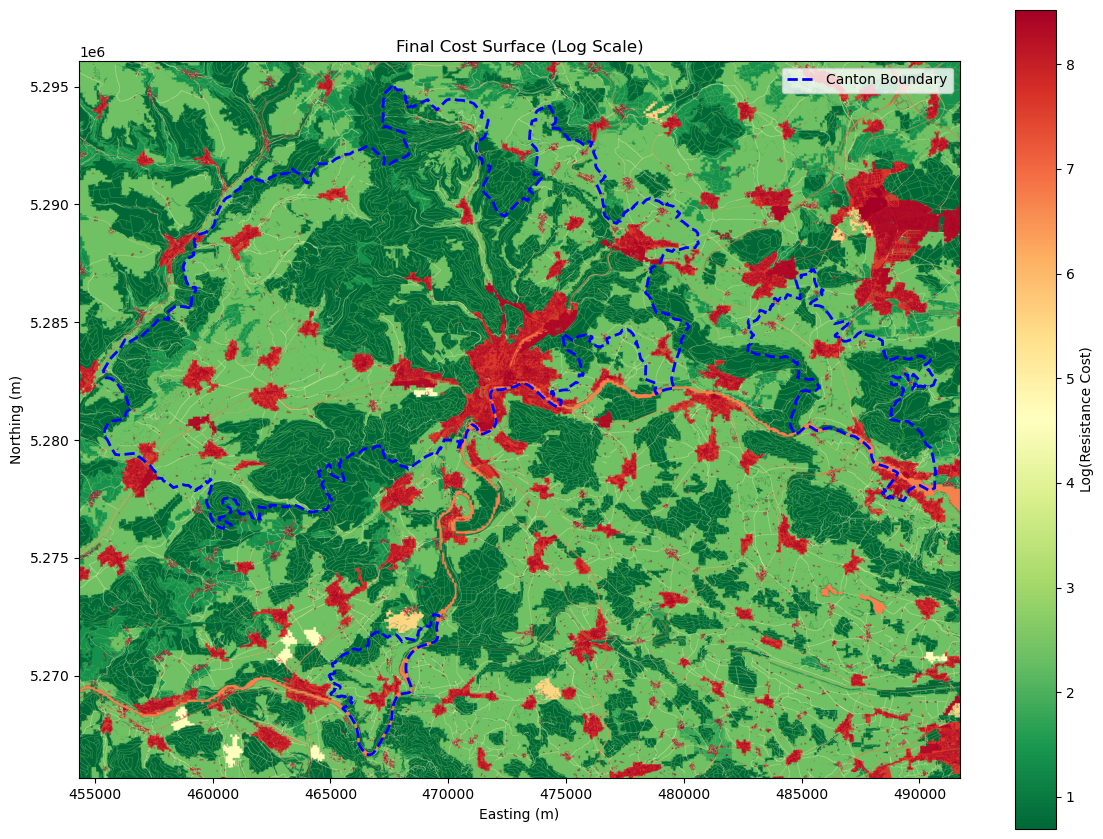

In [90]:
# --- Cell 11: Visualize Final Result ---
print("Plotting final cost surface...")

try:
    with rasterio.open(FINAL_RASTER) as src:
        cost_data = src.read(1)

        print(min(cost_data.flatten()), max(cost_data.flatten()))
        
        # Use a log scale for visualization
        cost_data_log = np.log1p(cost_data)
        
        fig, ax = plt.subplots(figsize=(12, 12))
        
        im = rasterio.plot.show(
            cost_data_log,
            transform=src.transform,
            ax=ax,
            cmap='RdYlGn_r'
        )
        
        cbar = fig.colorbar(im.images[0], ax=ax, shrink=0.7)
        cbar.set_label('Log(Resistance Cost)')
        
        # Plot the canton boundary on top
        gdf_sh_proj.boundary.plot(ax=ax, color='blue', linestyle='--', linewidth=2, label='Canton Boundary')
        
        ax.legend()
        ax.set_title("Final Cost Surface (Log Scale)")
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")
        
        plt.tight_layout()
        plt.show()

except NameError:
    print("!!! ERROR: 'gdf_sh_proj' not found. Please re-run Cell 4 (AOI Definition).")
except FileNotFoundError:
    print(f"!!! ERROR: File not found at '{FINAL_RASTER}'")
    print("Please make sure Cell 10 (Combine Final Raster) ran successfully.")